-------------------------------
-------------------------------
# Laboratorio #5 - IA (CC3085)
* Dulce Ambrosio - 231143
* Daniel Chet - 231177
* Gadiel Ocaña - 231270

-------------------------------
-------------------------------

-------------------------------
## Task 2.1 - Se preprara el entorno
-------------------------------

In [1]:
# Se instala la biblioteca gymnasium para crear entornos de aprendizaje por refuerzo
!pip install gymnasium


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Se realizan las importaciones necesarias para el código 
import gymnasium as gym # Crea el entorno
import numpy as np

In [3]:
# Se creal el entorno de FrozenLake (Diapositiva 10-12)
# Al basarse en Markov Decision Processes (MDP) se compone de
# - estados
# - acciones
# - recompensas 
# - transiciones entre estados
env = gym.make(
    "FrozenLake-v1",
    is_slippery=True, # El hielo resbala, lo que lo hace estocastico
    render_mode="rgb_array"
)

In [4]:
# Se exploran los estados y las acciones
# El mapa es 4x4 entonces son 16 estados
# Las acciones son: izquierda (0), abajo (1), derecha (2), arriba (3)
num_states = env.observation_space.n
num_actions = env.action_space.n

print("Número de estados:", num_states)
print("Número de acciones:", num_actions)

Número de estados: 16
Número de acciones: 4


-------------------------------
## Task 2.2 - Implementar Q-Learning
-------------------------------

In [5]:
# La Q-table guarda el valor de cada acción en cada estado, se inicializa con ceros
# Se utiliza la funcion Q(s,a) que representa la utilidad esperada de tomar la acción a en el estado s (Diapositiva 4)
Q = np.zeros((num_states, num_actions))

print(Q)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [6]:
# Se definen los hiperparámetros para el algoritmo Q-learning

alpha = 0.1      # Learning Rate / cuanto confiamos en la nueva informacion
gamma = 0.99     # Factor de descuento (Diapositiva 5) / que tanto se valoran las recompensas futuras
                 # cercano a 1 piensa a largo plazo 

epsilon = 1.0    # Exploración inicial / Controla exploración vs explotación (explora mucho, luego disminuye)
epsilon_decay = 0.999
epsilon_min = 0.01

episodes = 10000

In [7]:
# Se entrena el Q-learning (Diapositiva 6-9)

for episode in range(episodes):

    state, _ = env.reset()
    done = False

    while not done:

        # Elegir acción (Epsilon-Greedy) (Diapositiva 27-30)
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # explorar
        else:
            action = np.argmax(Q[state])  # explotar

        # Ejecutar acción
        new_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        # Fórmula Q-Learning (Diapositiva 22-25)
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[new_state]) - Q[state, action]
        )

        # Actualizar estado
        state = new_state

    # Reducir epsilon
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

In [8]:
# Se imprime la Q-table entrenada

print("Q-table entrenada:")
print(Q)

Q-table entrenada:
[[0.49532067 0.49548398 0.49516515 0.49305391]
 [0.34571854 0.29034154 0.37067682 0.47259665]
 [0.39084644 0.39792994 0.41927583 0.44864979]
 [0.27280988 0.26580608 0.30978532 0.43317929]
 [0.50033086 0.38557361 0.41629407 0.34628594]
 [0.         0.         0.         0.        ]
 [0.20894795 0.16295393 0.28700356 0.08998451]
 [0.         0.         0.         0.        ]
 [0.36345508 0.44991759 0.42090324 0.52157065]
 [0.50512302 0.55637976 0.38021924 0.42122053]
 [0.5313308  0.38332252 0.35799251 0.35501685]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.33742248 0.51981857 0.70234606 0.57263593]
 [0.73899421 0.83465572 0.77159285 0.71724878]
 [0.         0.         0.         0.        ]]


In [9]:
# Se ejecutan episodios de prueba

test_episodes = 10 # 10 episodios de prueba
wins = 0

for episode in range(test_episodes):

    state, _ = env.reset()
    done = False

    while not done:

        action = np.argmax(Q[state])  # puramente greedy

        new_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated
        state = new_state

        if reward == 1:
            wins += 1

In [10]:
# Se calcula el win rate

win_rate = (wins / test_episodes) * 100

print("Wins:", wins)
print("Win Rate:", win_rate, "%")

Wins: 3
Win Rate: 30.0 %


In [11]:
# Se visualiza un episodio por medio de renderizado

env = gym.make(
    "FrozenLake-v1",
    is_slippery=True,
    render_mode="human"
)

state, _ = env.reset()
done = False

while not done:

    action = np.argmax(Q[state])

    state, reward, terminated, truncated, _ = env.step(action)

    done = terminated or truncated

env.close()

c:\Users\dulce\AppData\Local\Programs\Python\Python313\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [12]:
# Se visualiza un episodio con detalles de cada paso

import time

actions = {
    0: "Izquierda",
    1: "Abajo",
    2: "Derecha",
    3: "Arriba"
}

env = gym.make(
    "FrozenLake-v1",
    is_slippery=True,
    render_mode="human"
)

state, _ = env.reset()
done = False
step = 0

while not done:

    action = np.argmax(Q[state])

    new_state, reward, terminated, truncated, _ = env.step(action)

    done = terminated or truncated

    print("Paso:", step)
    print("Estado actual:", state)
    print("Acción tomada:", actions[action])
    print("Nuevo estado:", new_state)
    print("Recompensa:", reward)
    print("----------------------")

    state = new_state
    step += 1

    time.sleep(0.5)

if reward == 1:
    print("El agente llegó a la meta !!")
else:
    print("El agente cayó en un agujero ")

env.close()

Paso: 0
Estado actual: 0
Acción tomada: Abajo
Nuevo estado: 0
Recompensa: 0
----------------------
Paso: 1
Estado actual: 0
Acción tomada: Abajo
Nuevo estado: 4
Recompensa: 0
----------------------
Paso: 2
Estado actual: 4
Acción tomada: Izquierda
Nuevo estado: 8
Recompensa: 0
----------------------
Paso: 3
Estado actual: 8
Acción tomada: Arriba
Nuevo estado: 9
Recompensa: 0
----------------------
Paso: 4
Estado actual: 9
Acción tomada: Abajo
Nuevo estado: 8
Recompensa: 0
----------------------
Paso: 5
Estado actual: 8
Acción tomada: Arriba
Nuevo estado: 4
Recompensa: 0
----------------------
Paso: 6
Estado actual: 4
Acción tomada: Izquierda
Nuevo estado: 0
Recompensa: 0
----------------------
Paso: 7
Estado actual: 0
Acción tomada: Abajo
Nuevo estado: 4
Recompensa: 0
----------------------
Paso: 8
Estado actual: 4
Acción tomada: Izquierda
Nuevo estado: 4
Recompensa: 0
----------------------
Paso: 9
Estado actual: 4
Acción tomada: Izquierda
Nuevo estado: 0
Recompensa: 0
---------------

-------------------------------
## Visualización de la política
-------------------------------

In [13]:
# Se definen las flechas de las acciones

import numpy as np

action_symbols = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

In [14]:
# Se crea la política derivada de la Q-table

policy = np.argmax(Q, axis=1)

In [15]:
# Se convierte la política en flechas

policy_symbols = [action_symbols[a] for a in policy]

In [16]:
# Se convierte en un mapa 4x4

policy_grid = np.array(policy_symbols).reshape(4,4)

In [17]:
# Muestra el mapa de la política 

print("Política aprendida:\n")

for row in policy_grid:
    print(" ".join(row))

Política aprendida:

↓ ↑ ↑ ↑
← ← → ←
↑ ↓ ← ←
← → ↓ ←


In [18]:
# Muestra el mapa del entorno

desc = env.unwrapped.desc.astype(str)

print("\nMapa del entorno:\n")

for row in desc:
    print(" ".join(row))


Mapa del entorno:

S F F F
F H F H
F F F H
H F F G


-------------------------------
## Mapa de calor de la Q-table
-------------------------------

In [19]:
# Se importan las librerias
import matplotlib.pyplot as plt

In [20]:
# Se obtiene el valor maximo de cada estado
state_values = np.max(Q, axis=1)

In [21]:
# Se convierte en matrix 4x4
value_grid = state_values.reshape(4,4)

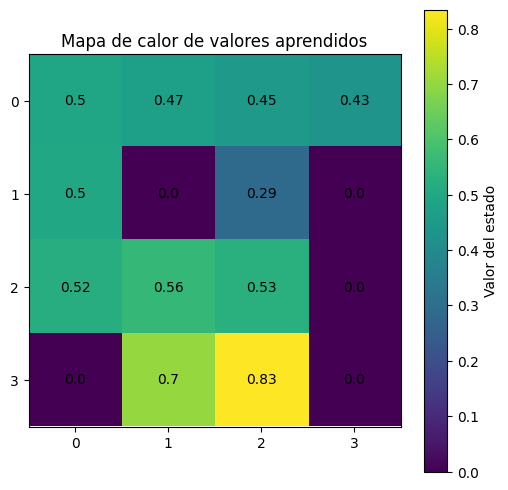

In [22]:
# Se crea el mapa de calor
plt.figure(figsize=(6,6))
plt.imshow(value_grid)
plt.colorbar(label="Valor del estado")

plt.title("Mapa de calor de valores aprendidos")
plt.xticks(range(4))
plt.yticks(range(4))

for i in range(4):
    for j in range(4):
        plt.text(j, i, round(value_grid[i, j], 2),
                 ha="center", va="center", color="black")

plt.show()